In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict ,Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel , Field
from langchain_core.messages import BaseMessage , HumanMessage
import os
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

e:\python\Langgraph\myenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", api_key=os.getenv('API_KEY'))

In [3]:
class ChatState(TypedDict):
    # base message is the initial message that the user sends to the chatbot, and it is required.
    messages : Annotated[list[BaseMessage] ,add_messages] 

In [4]:
llm = model

def chat_node(state:ChatState) -> ChatState:
    
    # take user query from the state
    messages = state['messages']

    # get response from the model
    response = llm.invoke(messages)
    
    # add response to the state
    return {'messages': [response]}



In [5]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node' , chat_node)


graph.add_edge(START , 'chat_node')
graph.add_edge('chat_node' , END)

chatbot = graph.compile(checkpointer=checkpointer)

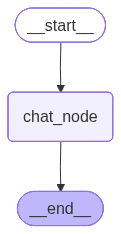

In [6]:
chatbot

In [7]:
intialState = {
    'messages': [HumanMessage(content="What is the capital of France?")]
}

chatbot.invoke(intialState)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
thread_id = '1'
while True:

    user_message = input("type here to continue the conversation...")
    print(f"user message: {user_message}")
    if user_message.strip().lower() in ['bye', 'exit', 'quit']:
        break
    config = { 'configurable' : { 'thread_id': thread_id } }
    res = chatbot.invoke({'messages': [HumanMessage(content=user_message)]} , config = config)['messages'][-1].content
    print(f"chatbot response: {res}")

user message: hi
chatbot response: [{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EqMCCqACAQw51sco/W02WcQqppKilNf9GSdMbjicfYXUx6VOpkIaS77Q0RyqOuZuXUsN5prsnuo+8om7t15M6Z9AHtBBqQknNafj6Ct9xroQX8BUGqa6xFKkIttdEq5OGnZN4MwPTwxhp6AsabGxfCXBX57XPLDtY7OTqYuL2lcpF3KPDKapJAiEZ7iCo0EsIU8AdC6lCJN13sLiCbQbvLmOz75Kr2X4GioTF7iN+wcMwvBKqThjihVDdlkvwmbcpXUHGFZZw7XuIfRVldqjLmT626kyXSfFAOzBzRsczT10TQ++yi49JQYO/KtmtJGSa2zBuC3bkvBiSrYlSlYXODZIp0VrmAlBKcYHPZ4x7eE/6fZ/dFxF+fdvWOx7t8F+xCCc6Y1B'}}]
user message: my name is amit
chatbot response: [{'type': 'text', 'text': 'Nice to meet you, Amit! How can I help you today?', 'extras': {'signature': 'Es0CCsoCAQw51seGnt6z8A7J1SUIvlrUL6Soqcdnqo6/f5A68aJbAMO8CBZf49CdGumh5cqj6Bx+e6e4iyzl+uvsMvIQ2yPPV4ImWiiLH/uIx3dZtfaBBJOetxhpjlVRkAIzNkc8m1mn1dqBgY+kyoxAb6+hA+T44duOPeahjJ60mRKBiP7gx8J0Krc+oVTtVquJJK+uGF7tyPYpWkmcDj3VcfqXssDgG/e74cOzaaHQOunTUui6kTPrpGxXNoGoWhO/oPi+qIX6s/Asa1zEAEkxY41Tj5nH7Gg4RvKHs5wE9w9hLYWRnK1n16TyDuBXV4/W/pQGm

e:\python\Langgraph\myenv\Lib\site-packages\langchain_google_genai\chat_models.py:2882: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


chatbot response: []
